# 041 迁移学习与适配

同一目标任务中，比较从零、冻结与不同微调协议。先检验完整性，再手算核验、完整重跑、查看选择与失败。只需CPU，无外部模型与数据下载。

In [1]:
from pathlib import Path
import os, sys, hashlib
candidates=[]
if os.environ.get('UNIT041_DIR'):
    candidates.append(Path(os.environ['UNIT041_DIR']).expanduser())
candidates += [Path.cwd(), Path.cwd()/'units'/'041', Path.cwd()/'dl-course-production'/'units'/'041']
unit=next((p.resolve() for p in candidates if (p/'experiment.py').is_file() and (p/'data').is_dir()),None)
if unit is None:
    raise RuntimeError('找不到041单元，请从单元目录运行，或设置UNIT041_DIR。')
expected={'experiment.py': 'd4d2d4221a0dab006d8c708f39901de91b2a1298d55173d7700dffb89be2c6f1', 'test_experiment.py': '18aef34f306f4269726611d97261005a08a79c56d618665f90e8d0eec247d68c', 'make_figures.py': 'f11e39000961a01e1362dc739938f8aa328bdb5d4fc5eaf7514a5b9fe504f5f2', 'figure-contract.json': 'e297a27b9f2d4c8c0ff28d09f226fbad44a930cdb33584b3b9b130d3728cd3e7', 'data/generate.py': '9fba36cbdaacca57a0f9cbbe6cecbbdd6c7d4e9260c26462a6ec2b96e90bcd00', 'data/source.csv': '8e378d24b4ae4fd84a02b7c4158d2e80ab75ce7b94e603e2fef679af285fe957', 'data/target_test.csv': '3fcd9ccd5089ad80135a611f270e2cee2c45706e45e089bc4899d16a230f2b54', 'data/target_train.csv': '9655201602ecbdb461ef62e6db8af22aa194cb76720595a38c20ad4ba4f1cfd6', 'data/target_validation.csv': '33c22da3ad65f6a3266dade462db9c9e8334826aa3975511170cdd5346bb0681', 'outputs/calculations.json': 'f1ef487c65ece4b75ca1b54c6c28d7a1e669d96941b8ef5d905a93e08e3181be', 'outputs/results.json.gz': '3cbf0f1cd2023a856ae83f89bb41174a1e14dbe373825507a2d043cb39c9d28f', 'outputs/summary.json': '5acb98ec60981f4669ba795a511bb1b2420dad0d136cf73b9d492904f17ee36a', 'figures/01_transfer_paths.png': 'fa40026477bedc3a5c8f367a61736353ac6c84524b3e6ca768a72aaad8a76400', 'figures/02_domain_and_task.png': '9170d5b09cde700f85ccbfd8af3abd88acc0257fa55af524d68fbceae057adcf', 'figures/03_information_loss.png': '56053755b8d086aa40486384d9d11be75edd86669afbf85b32907650c2de27bf', 'figures/04_hand_gradient_contributions.png': 'f590cc505542bf1436b3d6a368e8a484d5f086df529482d32c35a4d7dcd207d8', 'figures/05_hand_next_forward.png': '6dfeb4833083897533b3634f255d5dd543bff3f0ebe1a852d5e5720d0859970f', 'figures/06_freezing_is_not_detach.png': '50bf579bda2435cb2e8faf680d17a47b7202b24127111f625a231a77759b0f92', 'figures/07_data_boundary.png': 'f775eccdfab7eb6d4aaef02f67782e2c570e51d0a333fa05e284b452ff936baa', 'figures/08_all_test_results.png': '0d7f77b6a5d85ccb86091b0793650162c21ca45b51f14cf12b010d701a746085', 'figures/09_paired_negative_transfer.png': '59d6b9db3e9592fe4a1923676e311be651c44aa65e058a719695d87d9f2d6d8f', 'figures/10_actual_learning_curves.png': '0173ba4d45b6f5ff29ac44772e62e429c890f8affb7de6587fccaeadaa5b8c1a', 'figures/11_parameter_paths.png': 'b6c06b27593a22bfdc4e34b28716b853041834b9a5db4575ac66cda06bbc0c28', 'figures/12_prediction_surfaces.png': '143c9d034ba6d020b3bc15f10b784da2798477a28385d5a87736f58bffd2fb79', 'figures/13_representation_and_target.png': '3afe2bf20e489ce815443fb4f63414f18edae43989f9e8b8e1377807f5ba49c3', 'figures/14_validation_candidates.png': '8c53bf89b95449b87ae9faa2244d28148540fded0f30f8e1779c0667984708e0'}
for relative,digest in expected.items():
    path=unit/relative
    if not path.is_file() or hashlib.sha256(path.read_bytes()).hexdigest()!=digest:
        raise RuntimeError('完整性检查失败：'+relative+'；请使用同一版本代码、数据、结果和图。')
sys.path.insert(0,str(unit))
print('已核验',len(expected),'份代码、数据、结果及图；尚未导入实验模块。')


已核验 26 份代码、数据、结果及图；尚未导入实验模块。


## 1 环境与预算
实际打印运行版本；两档训练标签之外还各用128条验证标签，不能把这些监督隐藏。主实验目标神经预算一致，但源训练与闭式岭解另计。

In [2]:
import json, gzip, tempfile, platform, io, unittest
import numpy as np
import torch
import experiment as e
print({'python':platform.python_version(),'numpy':np.__version__,'torch':torch.__version__,'device':'cpu','dtype':'float64'})
summary=json.loads((unit/'outputs/summary.json').read_text())
print(json.dumps(summary['protocol'],ensure_ascii=False,indent=2))


{'python': '3.12.14', 'numpy': '2.3.5', 'torch': '2.7.1+cpu', 'device': 'cpu', 'dtype': 'float64'}
{
  "claim": "Target neural arms share update/sample budgets. Ridge arms use closed-form solves; neither wall-clock nor end-to-end pretraining budget is matched.",
  "lpft_initial_solves": 36,
  "methods": [
    "scratch",
    "random_probe",
    "pretrained_probe",
    "finetune_small",
    "finetune_equal",
    "lpft",
    "rbf_ridge"
  ],
  "penalties": [
    0.0001,
    0.01,
    0.1
  ],
  "per_nn_method_per_task_n_fit_count": 3,
  "rates": [
    0.03,
    0.1,
    0.3
  ],
  "ridge_solves": 108,
  "seeds": [
    11,
    23,
    37
  ],
  "source_n": 512,
  "source_sample_presentations": 921600,
  "source_steps": 600,
  "source_updates": 1800,
  "target_label_counts": [
    16,
    64
  ],
  "target_nn_candidates": 144,
  "target_nn_sample_presentations": 921600,
  "target_nn_updates": 23040,
  "target_steps": 160,
  "validation_labels_per_task": 128
}


## 2 同一批两样本完整手算
打印每条局部导数、逐样本五参数贡献、输入梯度、同步更新。下一格不复用旧中间结果。

In [3]:
first=e.hand_trace()
print(json.dumps(first,ensure_ascii=False,indent=2))


{
  "theta": [
    0.5493061443340548,
    -0.5493061443340548,
    0.0,
    2.0,
    0.1
  ],
  "x": [
    [
      1.0,
      0.0
    ],
    [
      0.0,
      1.0
    ]
  ],
  "y": [
    1.0,
    -0.4
  ],
  "z": [
    0.5493061443340548,
    -0.5493061443340548
  ],
  "h": [
    0.49999999999999994,
    -0.49999999999999994
  ],
  "prediction": [
    1.0999999999999999,
    -0.8999999999999999
  ],
  "error": [
    0.09999999999999987,
    -0.4999999999999999
  ],
  "loss_each": [
    0.004999999999999987,
    0.12499999999999994
  ],
  "risk": 0.06499999999999996,
  "local": {
    "dL_dli": [
      0.5,
      0.5
    ],
    "dli_dprediction": [
      0.09999999999999987,
      -0.4999999999999999
    ],
    "dp_dv": [
      0.49999999999999994,
      -0.49999999999999994
    ],
    "dp_db": [
      1,
      1
    ],
    "dp_dh": [
      2.0,
      2.0
    ],
    "dh_dz": [
      0.75,
      0.75
    ],
    "dz_da1": [
      1.0,
      0.0
    ],
    "dz_da2": [
      0.0,
      1.0

## 3 两种更新后的完整前向与下一次梯度
冻结与微调各自从同一旧初值开始。注意平均下降仍可能伴随一条样本损失上升。

In [4]:
for mode,key in [('grouped','theta_next_grouped'),('frozen','theta_next_frozen')]:
    next_trace=e.hand_trace(first[key])
    print(mode,json.dumps(next_trace,ensure_ascii=False,indent=2))


grouped {
  "theta": [
    0.5418061443340548,
    -0.5118061443340548,
    0.03,
    1.97,
    0.14
  ],
  "x": [
    [
      1.0,
      0.0
    ],
    [
      0.0,
      1.0
    ]
  ],
  "y": [
    1.0,
    -0.4
  ],
  "z": [
    0.5718061443340549,
    -0.4818061443340548
  ],
  "h": [
    0.5166844841417254,
    -0.44768892452696485
  ],
  "prediction": [
    1.157868433759199,
    -0.7419471813181208
  ],
  "error": [
    0.1578684337591989,
    -0.34194718131812074
  ],
  "loss_each": [
    0.012461221188791286,
    0.058463937405703874
  ],
  "risk": 0.03546257929724758,
  "local": {
    "dL_dli": [
      0.5,
      0.5
    ],
    "dli_dprediction": [
      0.1578684337591989,
      -0.34194718131812074
    ],
    "dp_dv": [
      0.5166844841417254,
      -0.44768892452696485
    ],
    "dp_db": [
      1,
      1
    ],
    "dp_dh": [
      1.97,
      1.97
    ],
    "dh_dz": [
      0.7330371438471991,
      0.7995746268558895
    ],
    "dz_da1": [
      1.0,
      0.0
    

## 4 冻结不是detach
输入明确需要梯度。参数冻结允许信号穿过固定模块，detach和no_grad切断该路径。eval仅改变模块行为状态。

{
  "frozen": {
    "x_grad": [
      [
        0.04165024989589065,
        -0.04165024989589065
      ],
      [
        -0.20653574389770873,
        0.20653574389770873
      ]
    ],
    "backbone_grad": null,
    "head_grad": [
      0.15067681578667075,
      -0.19999999999999996
    ]
  },
  "detach": {
    "x_grad": null,
    "backbone_grad": null,
    "head_grad": [
      0.15067681578667075,
      -0.19999999999999996
    ]
  },
  "no_grad": {
    "x_grad": null,
    "backbone_grad": null,
    "head_grad": [
      0.15067681578667075,
      -0.19999999999999996
    ]
  },
  "eval_only": {
    "x_grad": [
      [
        0.04165024989589065,
        -0.04165024989589065
      ],
      [
        -0.20653574389770873,
        0.20653574389770873
      ]
    ],
    "backbone_grad": [
      0.07572772708343753,
      -0.3755195343594704,
      -0.29979180727603283
    ],
    "head_grad": [
      0.15067681578667075,
      -0.19999999999999996
    ]
  }
}


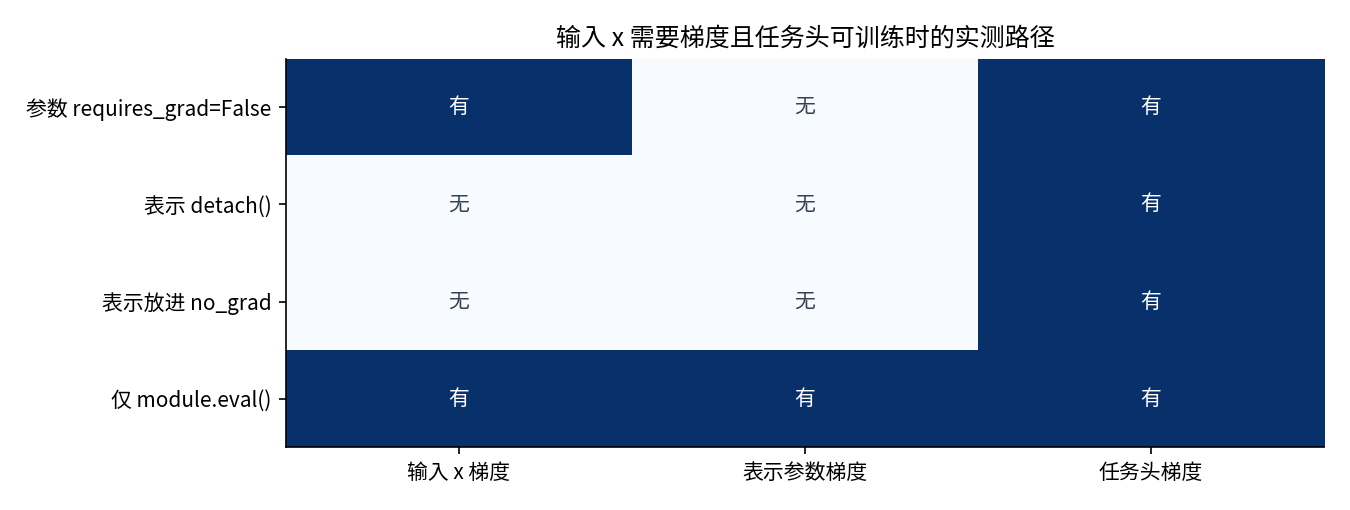

In [5]:
demo=e.freeze_demo()
print(json.dumps(demo,ensure_ascii=False,indent=2))
from IPython.display import display, Image
display(Image(filename=str(unit/'figures/06_freezing_is_not_detach.png'),width=900))


## 5 独立参考与防错测试
中心差分核对三个手算点；独立NumPy重建全部24840次更新；检查108个岭解、252个指标、预测与验证选择。失败抛出异常，不依赖bare assert。

In [6]:
import test_experiment as tests
buffer=io.StringIO()
suite=unittest.defaultTestLoader.loadTestsFromTestCase(tests.Test041)
report=unittest.TextTestRunner(stream=buffer,verbosity=1).run(suite)
print(buffer.getvalue())
if not report.wasSuccessful():
    raise RuntimeError('独立测试未通过')
print(json.dumps(tests.ERRORS,indent=2))


...........
----------------------------------------------------------------------
Ran 11 tests in 2.768s

OK

{
  "hand_fd_max_abs": 3.160016692760337e-11,
  "training_theta_max_abs": 9.992007221626409e-16,
  "training_mse_max_abs": 3.469446951953614e-16,
  "independently_reconstructed_updates": 24840,
  "ridge_stationarity_max_abs": 2.2567837626875226e-16
}


## 6 全部实验重新训练并比较字节
这格实际重跑3次源训练、144个目标神经候选、108个目标岭候选和36个LPFT初始化解，不使用保存的模型。新结果先写临时目录，原版outputs不被覆盖。

In [7]:
with tempfile.TemporaryDirectory(prefix='unit041-replay-') as temporary:
    replay=e.run(output=Path(temporary))
    for name,digest in replay['sha256'].items():
        if digest!=expected['outputs/'+name]:
            raise RuntimeError('重跑摘要不同：'+name)
    print({'files':replay['sha256'],'bytes':replay['bytes']})
    print('三份输出与原版逐字节一致；临时目录随后清理。')


{'files': {'results.json.gz': '3cbf0f1cd2023a856ae83f89bb41174a1e14dbe373825507a2d043cb39c9d28f', 'summary.json': '5acb98ec60981f4669ba795a511bb1b2420dad0d136cf73b9d492904f17ee36a', 'calculations.json': 'f1ef487c65ece4b75ca1b54c6c28d7a1e669d96941b8ef5d905a93e08e3181be'}, 'bytes': {'results.json.gz': 3292034, 'summary.json': 9086, 'calculations.json': 4851}}
三份输出与原版逐字节一致；临时目录随后清理。


## 7 压缩契约和测试边界
确定性gzip保留JSON全部字节。测试标签只在所有候选和验证选择完成后解析；这是可审计代码顺序，不是访问控制。

In [8]:
packed=(unit/'outputs/results.json.gz').read_bytes()
raw=gzip.decompress(packed)
result=json.loads(raw)
info=summary['packed_result']
if hashlib.sha256(raw).hexdigest()!=info['raw_sha256']:
    raise RuntimeError('解压原始字节摘要不同')
print(info)
print(result['events'])
print({k:summary[k] for k in ['source_history_rows','target_history_rows','test_prediction_rows','metric_rows']})


{'filename': 'results.json.gz', 'gzip': {'filename': '', 'level': 9, 'mtime': 0}, 'packed_bytes': 3292034, 'packed_sha256': '3cbf0f1cd2023a856ae83f89bb41174a1e14dbe373825507a2d043cb39c9d28f', 'raw_bytes': 8989849, 'raw_sha256': '3dcffe766baaf1cd21f7117170f680bd5b96505df81fb0b42ff5f4fa1a9fd7b4'}
['all_fixture_bytes_verified', 'source_train_target_train_validation_labels_parsed', 'all_candidate_models_fitted', 'all_validation_selections_frozen', 'test_labels_parsed_after_selection']
{'source_history_rows': 1803, 'target_history_rows': 23184, 'test_prediction_rows': 43008, 'metric_rows': 84}


## 8 看完整结果而非最成功的一个种子
RBF是确定性解，三次重复数值不是三份独立数据。三种子仍共用一个固定数据拆分，不给出数据层面的显著性结论。

related 16 scratch mean MSE= 0.009406 paired Δ= [0.0, 0.0, 0.0]
related 16 random_probe mean MSE= 0.27763 paired Δ= [0.527421, 0.13762, 0.13963]
related 16 pretrained_probe mean MSE= 0.007071 paired Δ= [-0.001846, -0.002584, -0.002577]
related 16 finetune_small mean MSE= 0.006982 paired Δ= [-0.001926, -0.002681, -0.002666]
related 16 finetune_equal mean MSE= 0.006939 paired Δ= [-0.001936, -0.002755, -0.00271]
related 16 lpft mean MSE= 0.007104 paired Δ= [-0.001801, -0.002562, -0.002544]
related 16 rbf_ridge mean MSE= 0.046418 paired Δ= [0.037555, 0.036712, 0.036768]
related 64 scratch mean MSE= 0.007642 paired Δ= [0.0, 0.0, 0.0]
related 64 random_probe mean MSE= 0.260887 paired Δ= [0.507253, 0.110274, 0.142207]
related 64 pretrained_probe mean MSE= 0.006818 paired Δ= [-0.000645, -0.000939, -0.000889]
related 64 finetune_small mean MSE= 0.006687 paired Δ= [-0.000766, -0.00108, -0.00102]
related 64 finetune_equal mean MSE= 0.006457 paired Δ= [-0.00097, -0.001334, -0.001251]
related 64 lp

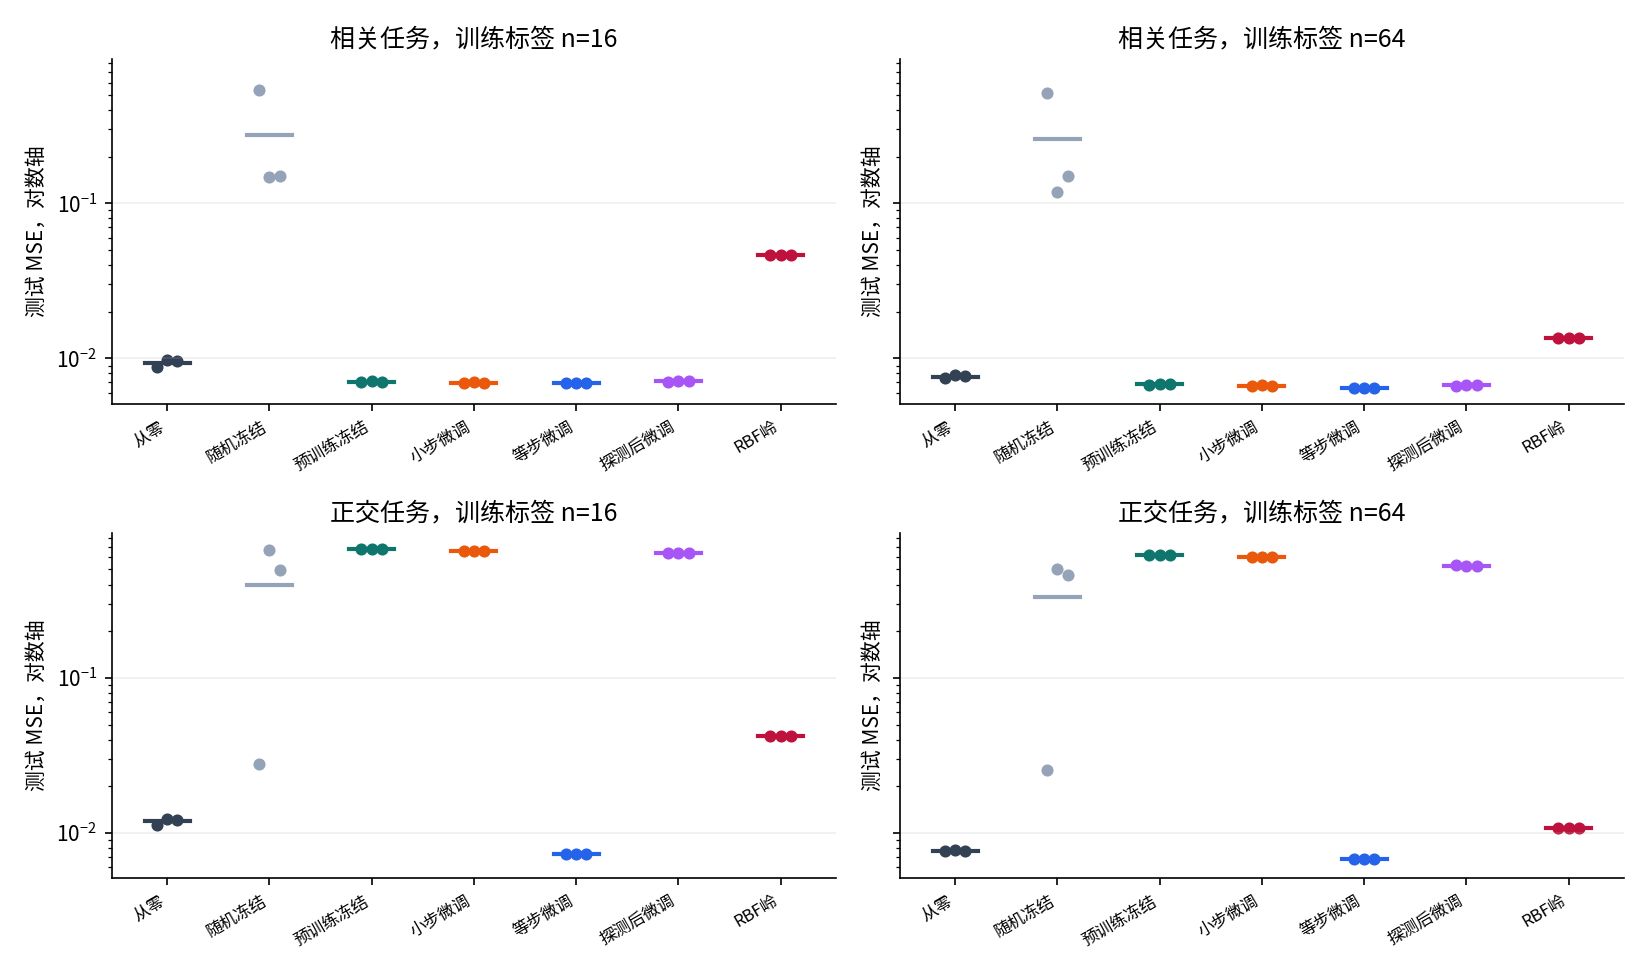

In [9]:
for row in result['summary']:
    print(row['task'],row['n'],row['method'],'mean MSE=',round(row['mean_test_mse'],6),'paired Δ=',[round(v,6) for v in row['paired_delta_vs_scratch']])
display(Image(filename=str(unit/'figures/08_all_test_results.png'),width=1000))


## 9 检查正交任务的候选选择
每个方法展示全部三个验证误差；随后查看已经选定的测试结果。小步失败必须与等步恢复同时报告。

scratch validation= [0.010071, 0.00883, 0.006379] selected= 2 test= 0.007591
random_probe validation= [0.025264, 0.02263, 0.121621] selected= 1 test= 0.025341
pretrained_probe validation= [0.635885, 0.635867, 0.636155] selected= 1 test= 0.616504
finetune_small validation= [0.652083, 0.641787, 0.603073] selected= 2 test= 0.599701
finetune_equal validation= [0.055406, 0.005728, 0.005767] selected= 1 test= 0.006773
lpft validation= [0.631485, 0.617099, 0.515083] selected= 2 test= 0.530711
rbf_ridge validation= [0.014967, 0.013965, 0.053881] selected= 1 test= 0.010835


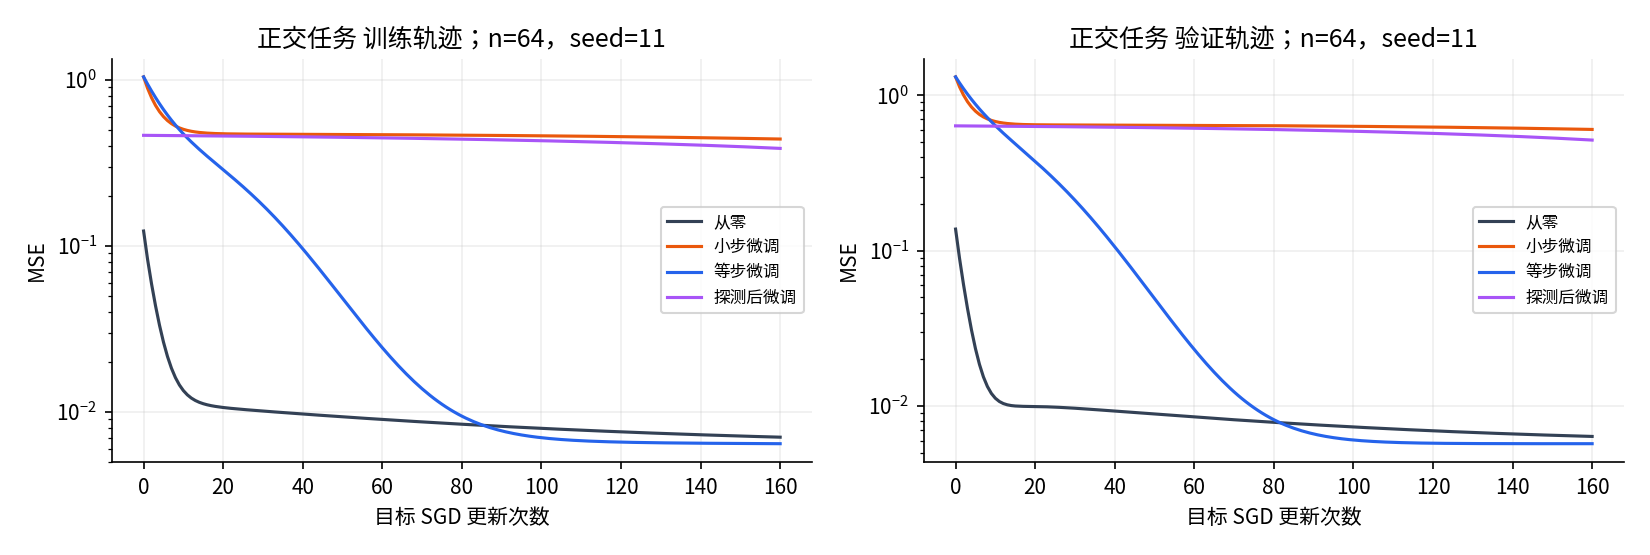

In [10]:
group=next(g for g in result['target_groups'] if g['seed']==11 and g['task']=='orthogonal' and g['n']==64)
for run in group['runs']:
    print(run['method'],'validation=',[round(c['validation_mse'],6) for c in run['candidates']],'selected=',run['selected'],'test=',round(run['predictions']['test']['mse'],6))
display(Image(filename=str(unit/'figures/10_actual_learning_curves.png'),width=1000))


## 10 由参数轨迹到预测函数
下图是已完成实验的解释。没有用这些测试图反过来更改当前配置。坐标外推区域在正文中明确标出。

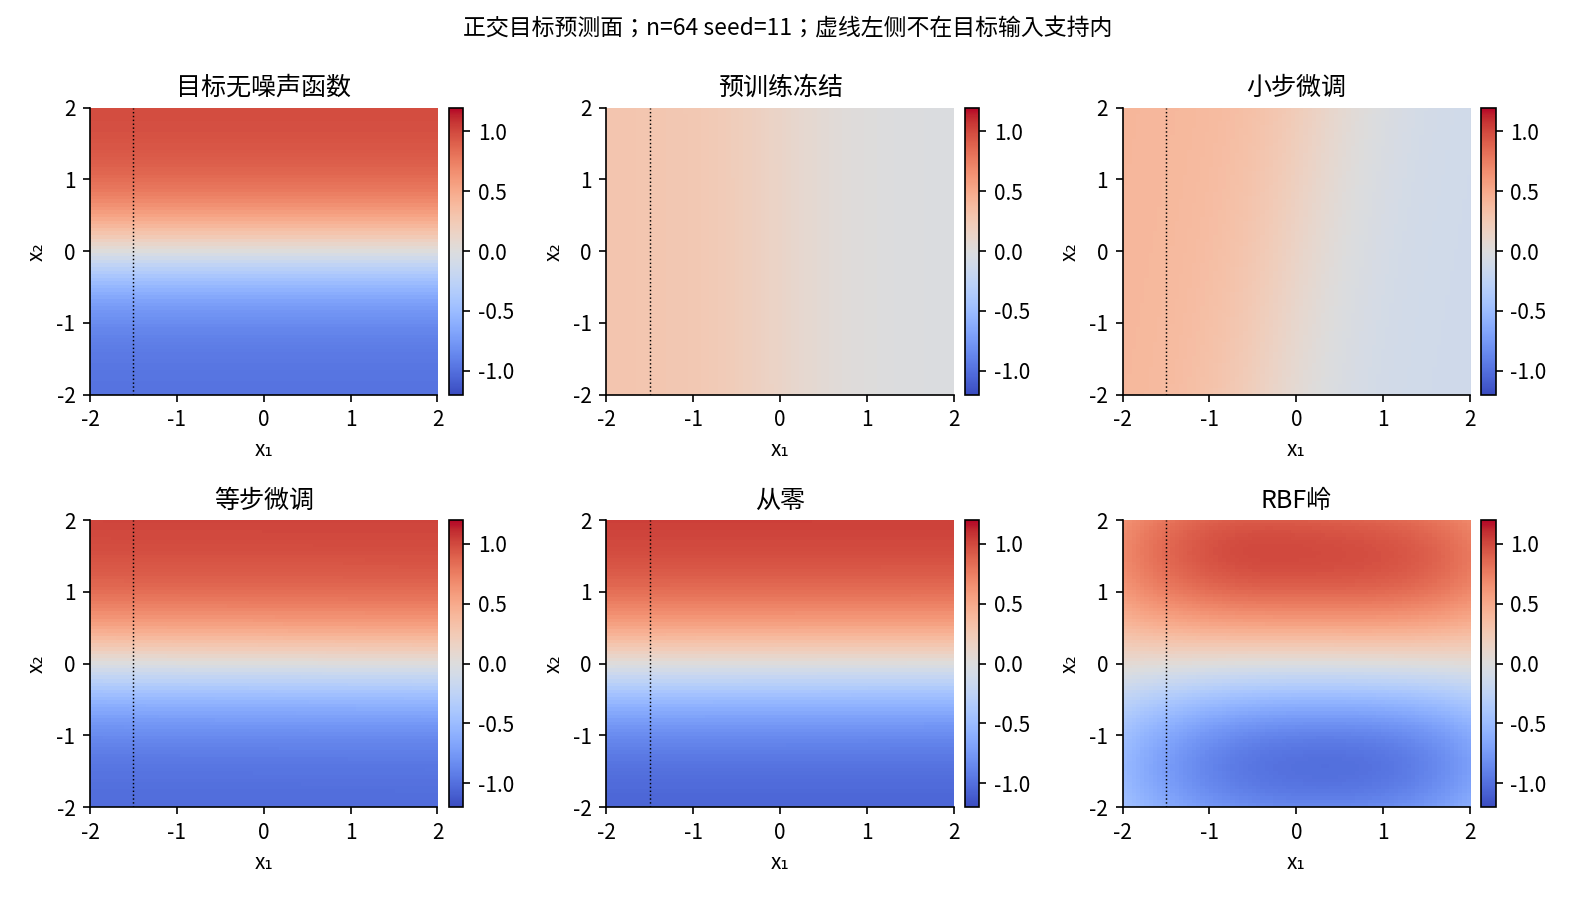

scratch initial= [0.01025783017595525, 0.4079242620929885, 0.0, 1.0, 0.0] final= [-0.0019485711534215555, 0.9990485278359698, 0.024909821459292995, 1.0829970116679106, -0.014456944005417569]
finetune_small initial= [1.0640368420344455, 0.0020288088321226043, -0.007832359680891694, 1.0, 0.0] final= [1.038591166082914, -0.15413310493197893, 0.01349186292005488, -0.26654529579591374, 0.14299921327363868]
finetune_equal initial= [1.0640368420344455, 0.0020288088321226043, -0.007832359680891694, 1.0, 0.0] final= [0.0053539290621600465, 1.0878799332323383, 0.008434615280793999, 1.042139782050076, -0.003032192098475292]
lpft initial= [1.0640368420344455, 0.0020288088321226043, -0.007832359680891694, -0.1625250315786701, 0.13174815979921217] final= [0.9954537661897255, -0.3958097141326498, 0.02651748900858152, -0.4188338454836421, 0.155932390025353]


In [11]:
display(Image(filename=str(unit/'figures/12_prediction_surfaces.png'),width=1000))
for method in ['scratch','finetune_small','finetune_equal','lpft']:
    run=next(r for r in group['runs'] if r['method']==method)
    chosen=run['candidates'][run['selected']]
    print(method,'initial=',chosen['initial'],'final=',chosen['theta'])


## 11 自己重算一个配对差与设计下一步
比较同一seed、任务、标签量。若接着改学习率或步数，应另建新的开发/测试拆分，完整报告搜索与源训练成本。

In [12]:
index={(r['seed'],r['task'],r['n'],r['method']):r for r in result['metrics']}
for seed in e.SEEDS:
    base=index[(seed,'orthogonal',64,'scratch')]['test_mse']
    for method in ['pretrained_probe','finetune_small','finetune_equal','lpft']:
        value=index[(seed,'orthogonal',64,method)]['test_mse']
        print(seed,method,'Δ=',value-base)
print('完成有限合成实验。未测试新Anaconda求解、GPU、Jupyter浏览器界面或socket传输。')


11 pretrained_probe Δ= 0.6089126249216941
11 finetune_small Δ= 0.5921096516887939
11 finetune_equal Δ= -0.0008177985033401359
11 lpft Δ= 0.5231197693221024
23 pretrained_probe Δ= 0.6086276365613797
23 finetune_small Δ= 0.5920946119623206
23 finetune_equal Δ= -0.0009356694183201191
23 lpft Δ= 0.5155690100127
37 pretrained_probe Δ= 0.6088466726646518
37 finetune_small Δ= 0.592171153083047
37 finetune_equal Δ= -0.0007931392680760336
37 lpft Δ= 0.5191935642723642
完成有限合成实验。未测试新Anaconda求解、GPU、Jupyter浏览器界面或socket传输。
